# Multi-Head Attention From Scratch

### Check torch version

In [34]:
# Verify torch version
from importlib.metadata import version
print("torch version: ", version("torch"))

torch version:  2.7.0+cu128


### Dimension notations

+ T: sequence length, the number of tokens

+ max_T: max sequence length

+ B: batch size

+ D: embedding dimension

+ H: the number of heads

+ D_h: embedding dimension of each head

+ D_h * H = D

### Implementation

In [35]:
import torch 
import torch.nn as nn
import torch.nn.functional as F

import math
import seaborn as sns

#### (I) Model arguments class 

In [36]:
# use dataclass to set up model arguments
from dataclasses import dataclass

@dataclass
class ModelArgs:
    H: int # number of heads
    D: int # embedding dimension of q, k
    max_T: int # max sequence length
    dropout: float 

In [37]:
# check ModelArgs
args = ModelArgs(H = 8, D = 128, max_T = 512, dropout = 0.1)
# print
print("check args: ", args.H, args.D, args.max_T, args.dropout)

check args:  8 128 512 0.1


#### (II) Multi-head attention class

In [38]:
# MultiHeadAttention from scratch
class MultiHeadAttention(nn.Module):
    
    def __init__(self, args: ModelArgs, is_causal = False):
        # inherit from nn.Module
        super().__init__()

        # set parameters
        self.H = args.H
        self.D = args.D
        assert self.D % self.H == 0
        self.D_h = self.D // self.H # D_h is each head embedding dimension
        self.is_causal = is_causal
        
        # linear transformtion layers
        # shape for Wq, Wk, Wv, Wo = [D, D]
        self.Wq = nn.Linear(self.D, self.D, bias = False)
        self.Wk = nn.Linear(self.D, self.D, bias = False)
        self.Wv = nn.Linear(self.D, self.D, bias = False)
        self.Wo = nn.Linear(self.D, self.D, bias = False)

        # dropout layer
        self.res_dropout = nn.Dropout(args.dropout)

        # mask
        if is_causal:
            mask = torch.full(
                (1, 1, args.max_T, args.max_T), 
                float("-inf"))
            mask = torch.triu(mask, diagonal=1)
            self.register_buffer("mask", mask) # register_buffer(name, tensor) tells the program this is not a model parameter
    
    def forward(self, q, k, v):
        # q, k, v shape = [B, T, D]
        B, T = q.shape[0], q.shape[1] 
        D = self.D
        H, D_h = self.H, self.D_h

        # step 1: linear transformtion with W
        # [B, T, D] * [D, D] -> [B, T, D]
        # shape for Q, K, V = [B, T, D]
        Q = self.Wq(q)
        K = self.Wk(k)
        V = self.Wv(v)

        # step 2: split into multiple heads
        # [B, T, D] = [B, T, H, D_h] where D = H * D_h
        # shape for Q, K, V = [B, T, H, D_h]
        Q = Q.view(B, T, H, D_h)
        K = K.view(B, T, H, D_h)
        V = V.view(B, T, H, D_h)

        # step 3: switch positions for T and H
        # [B, T, H, D_h] -> [B, H, T, D_h]
        # shape for Q, K, V = [B, H, T, D_h]
        Q = Q.transpose(1, 2)
        K = K.transpose(1, 2)
        V = V.transpose(1, 2)

        # step 4: compute attention score S
        # S = (Q K^T) / sqrt(D_h)
        # shape for S = [B, H, T, D_h] * [B, H, D_h, T] -> [B, H, T, T]
        S = torch.matmul(Q, K.transpose(2, 3)) / math.sqrt(D_h)

        # step 5: mask
        # shape for S = [B, H, T, T]
        if self.is_causal:
            S = S + self.mask[:, :, :T, :T]

        # step 6: compute attention probabiloity S_prob by softmax
        # normalize the last dimension T
        # shape for S_prob = [B, H, T, T]
        S_prob = F.softmax(S, dim=-1).type_as(Q)

        # step 7: compute weighted V
        # S_prob * V -> [B, H, T, T] * [B, H, T, D_h] -> [B, H, T, D_h]
        # shape for output: [B, H, T, D_h]
        output = torch.matmul(S_prob, V)

        # step 8: concatenate multiple heads
        # [B, H, T, D_h] -> [B, T, H, D_h] -> [B, T, D]
        # shape for output: [B, T, D]
        output = output.transpose(1, 2).contiguous().view(B, T, D)

        # step 9: final linear transformation layer + residual dropout
        # [B, T, D] * [D, D] -> [B, T, D]
        # shape for output: [B, T, D]
        output = self.Wo(output)
        output = self.res_dropout(output)

        return output, S_prob

### Tests for two cases (without and with causal)

#### Case 1: with causal

In [39]:
# test
# reproducible random numbers
torch.manual_seed(42)

# model configuration
args = ModelArgs(
    H=2,          # 2 attention heads
    D=8,          # embedding dimension
    max_T=16,     # maximum sequence length
    dropout=0.0   # disable dropout while testing
)

# input dimensions
B = 2
T = 4
D = args.D

# q, k, v all have shape [B, T, D]
q = torch.randn(B, T, D)
k = torch.randn(B, T, D)
v = torch.randn(B, T, D)

print("q shape:", q.shape)
print("k shape:", k.shape)
print("v shape:", v.shape)


q shape: torch.Size([2, 4, 8])
k shape: torch.Size([2, 4, 8])
v shape: torch.Size([2, 4, 8])


output shape: torch.Size([2, 4, 8])
attention probability shape: torch.Size([2, 2, 4, 4])


<Axes: >

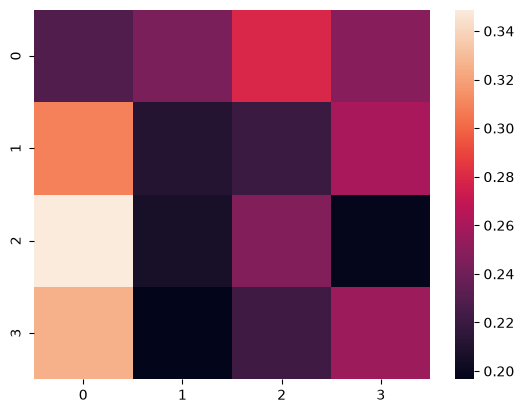

In [40]:
# Case 1: without causal
# create MHA
mha = MultiHeadAttention(args, is_causal=False)

# forward pass
output, attention_prob = mha(q, k, v)

print("output shape:", output.shape)
print("attention probability shape:", attention_prob.shape)

# show the first head
sns.heatmap(attention_prob[0, 0].detach().numpy())

#### Case 2: with causal

output shape: torch.Size([2, 4, 8])
attention probability shape: torch.Size([2, 2, 4, 4])


<Axes: >

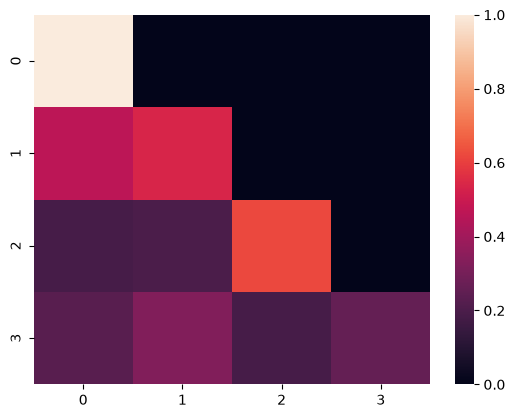

In [41]:
# Case 2: with causal
# create MHA
mha = MultiHeadAttention(args, is_causal=True)

# forward pass
output, attention_prob = mha(q, k, v)

print("output shape:", output.shape)
print("attention probability shape:", attention_prob.shape)

# show the first head
sns.heatmap(attention_prob[0, 0].detach().numpy())